In [ ]:
!unzip movies.zip -d ./tmp

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the dataset
ds = pd.read_csv('./tmp/movies.csv')
print(ds.shape, ds.columns)
selected_features=['genres','keywords','tagline','cast','director']
for feature in selected_features:
    # Handle NaN and convert to string
    ds[feature] = ds[feature].fillna('').astype(str)
    # Remove extra spaces and replace pipes with spaces
    ds[feature] = ds[feature].str.strip()
    ds[feature] = ds[feature].str.replace(r'\s+', ' ', regex=True)  # Multiple spaces -> single space
    ds[feature] = ds[feature].str.replace('|', ' ')

# Combine features with better handling
def combine_features(row):
    """Safely combine movie features"""
    parts = []
    for feature in selected_features:
        value = str(row[feature]).strip()
        if value and value.lower() != 'nan':
            parts.append(value)
    
    combined = ' '.join(parts).strip()
    # Ensure non-empty result
    return combined if combined else f"movie: {row['title']}"

_combined_features = ds.apply(combine_features, axis=1)
# Display the first few rows of the dataframe
print(ds.head())

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Fit and transform 
tfidf_matrix = tfidf_vectorizer.fit_transform(_combined_features)

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.tail()

(4803, 24) Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='object')
   index     budget                                    genres  \
0      0  237000000  Action Adventure Fantasy Science Fiction   
1      1  300000000                  Adventure Fantasy Action   
2      2  245000000                    Action Adventure Crime   
3      3  250000000               Action Crime Drama Thriller   
4      4  260000000          Action Adventure Science Fiction   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectr

,1970s,3d,aaron,about,abuse,action,adam,adams,addiction,adult,...,wrong,year,years,york,you,young,your,zach,zoe,zombie
4798,0.0,0.0,0.0,0.0,0.0,0.106439,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4799,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4800,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4801,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4802,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# Define the query
query = "A movie about zombie"

# Transform the query using the same TF-IDF vectorizer
query_tfidf = tfidf_vectorizer.transform([query])

# Calculate cosine similarity between the query and all documents
cosine_similarities = cosine_similarity(query_tfidf, tfidf_matrix).flatten()

ds['cosine_similarity'] = cosine_similarities

reranked_df = ds.sort_values(by='cosine_similarity', ascending=False).reset_index(drop=True)

reranked_df.head(10)

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director,cosine_similarity
0,4566,0,,NaN,325579,,en,Diamond Ruff,"Action - Orphan, con artist, crime boss and mi...",0.165257,...,[],Released,,Diamond Ruff,2.4,4,,[],,0.546415
1,4657,0,,NaN,320435,,en,UnDivided,UnDivided documents the true story of how a su...,0.010607,...,[],Released,,UnDivided,0.0,0,,[],,0.546415
2,4314,1200000,,NaN,137955,,en,Crowsnest,"In late summer of 2011, five young friends on ...",0.057564,...,[],Released,,Crowsnest,4.8,12,,[],,0.546415
3,4068,0,,NaN,371085,,en,Sharkskin,The Post War II story of Manhattan born Mike E...,0.027801,...,[],Released,,Sharkskin,0.0,0,,[],,0.546415
4,4674,0,,NaN,194588,,en,Short Cut to Nirvana: Kumbh Mela,Every 12 years over 70 million pilgrims gather...,0.004998,...,[],Released,,Short Cut to Nirvana: Kumbh Mela,0.0,0,,[],,0.472127
5,4118,0,,NaN,325140,,en,Hum To Mohabbat Karega,"Raju, a waiter, is in love with the famous TV ...",0.001186,...,[],Released,,Hum To Mohabbat Karega,0.0,0,,[],,0.472127
6,4633,0,,NaN,300327,,en,Death Calls,An action-packed love story on the Mexican bor...,0.005883,...,[],Released,,Death Calls,0.0,0,,[],,0.401501
7,2308,15000000,Horror,NaN,11683,cage dystopia survivor zombie zombie apocalypse,en,Land of the Dead,The world is full of zombies and the survivors...,15.262492,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,The dead shall inherit the Earth.,Land of the Dead,6.0,381,Simon Baker John Leguizamo Dennis Hopper Rober...,"[{'name': 'Marci Liroff', 'gender': 1, 'depart...",George A. Romero,0.391459
8,3147,9500000,Horror Science Fiction,NaN,106845,reality tv conspiracy zombie zombie apocalypse,en,Re-Kill,"Five years after a zombie outbreak, the men an...",5.346205,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,We are the endangered species.,Re-Kill,4.9,34,Roger Cross Scott Adkins Daniella Alonso Bruce...,"[{'name': 'Valeri Milev', 'gender': 0, 'depart...",Valeri Milev,0.388622
9,4504,0,,NaN,331493,,en,Light from the Darkroom,Light in the Darkroom is the story of two best...,0.012942,...,[],Released,,Light from the Darkroom,0.0,0,,[],,0.380984


In [46]:
!uv pip install rank_bm25

Using Python 3.12.3 environment at: /home/admin/_github/massimodipaolo/ai-crash-course/.venv
Resolved 2 packages in 266ms                                         
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/8.38 KiB            
⠙ Preparing packages... (0/1)---------- 8.38 KiB/8.38 KiB           
Prepared 1 package in 23ms                                                        
Installed 1 package in 1ms                                  
 + rank-bm25==0.2.2


### BM25 Algorithm

BM25 (Best Matching 25) is a ranking function used in information retrieval to score and rank documents based on their relevance to a query. 

It's an 
improvement over the traditional TF-IDF approach and is widely used in search engines like `Elasticsearch` and `Lucene`.

It's also used by many vector databases for `hybrid search`, combining `BM25` with `vector similarity` to enhance retrieval quality.

#### How BM25 Works

The BM25 formula is:

```
BM25 = IDF * (tf * (k1 + 1)) / (tf + k1 * (1 - b + b * (|d| / avgdl)))
```

Where:
- **IDF** (Inverse Document Frequency): Measures how rare a term is across the entire document collection
- **tf** (Term Frequency): How often the term appears in the current document
- **k1**: A tuning parameter that controls the term frequency saturation
- **b**: A tuning parameter that controls the document length normalization
- **|d|**: The length of the document (number of terms)
- **avgdl**: The average document length in the collection

#### Key Components

   1. **IDF Component**: Measures the importance of a term across the entire document collection
      ```
      IDF = log((N - n + 0.5) / (n + 0.5))
      ```
      Where N is total documents and n is documents containing the term

   2. **Term Frequency Saturation**: Unlike TF-IDF, BM25 applies saturation to term frequency to prevent very long documents from dominating

   3. **Document Length Normalization**: BM25 includes a length normalization factor that adjusts scores based on document length

#### Why BM25 Improves Over TF-IDF

   1. **Term Frequency Saturation**
   - **TF-IDF**: Linearly increases with term frequency (long documents get higher scores)
   - **BM25**: Applies saturation, so after a certain point, additional occurrences don't significantly increase the score

   2. **Better Handling of Document Length**
   - **TF-IDF**: Doesn't account for document length differences
   - **BM25**: Normalizes scores by document length, preventing very long documents from being unfairly favored

   3. **More Realistic Scoring**
   - **TF-IDF**: Simple multiplication of TF and IDF
   - **BM25**: More sophisticated formula that better reflects relevance

   4. **Robustness to Query Length**
   - **TF-IDF**: Struggles with multi-term queries
   - **BM25**: Handles multi-term queries naturally through its formula structure

   5. **Tunable Parameters**
   BM25 has parameters (k1, b) that can be tuned for specific use cases, making it more flexible than the fixed TF-IDF approach.

#### Practical Example

Consider a query "machine learning":
- **TF-IDF**: A document with 100 occurrences of "machine learning" gets much higher score than one with 10 occurrences
- **BM25**: The 100-occurrence document gets a higher score, but not proportionally higher due to saturation

#### Advantages in Practice

1. **Better Ranking Quality**: Produces more intuitive and relevant search results
2. **Less Sensitive to Document Length**: Fairer comparison between short and long documents
3. **More Stable**: Less prone to extreme score variations
4. **Industry Standard**: Widely adopted in modern search engines and information retrieval systems

BM25 essentially fixes the main weaknesses of TF-IDF by introducing saturation, normalization, and a more sophisticated mathematical foundation for scoring 
relevance.

TF-IDF vs BM25 COMPARISON

📚 THEORETICAL DIFFERENCES

                Aspect                         TF-IDF                              BM25
Term Frequency Formula                    log(1 + tf)                    tf / (k1 + tf)
       Document Length          Normalized implicitly  Explicit normalization (b param)
          Score Growth  Logarithmic (never saturates)    Asymptotic (saturates quickly)
            Saturation            No saturation point  Saturates at k1/(1-b+b*dl/avgdl)
              Best For Short documents, exact matches Long documents, relevance ranking
    Computational Cost      Lower (matrix operations) Higher (per-document calculation)


📊 SCORING FUNCTION COMPARISON



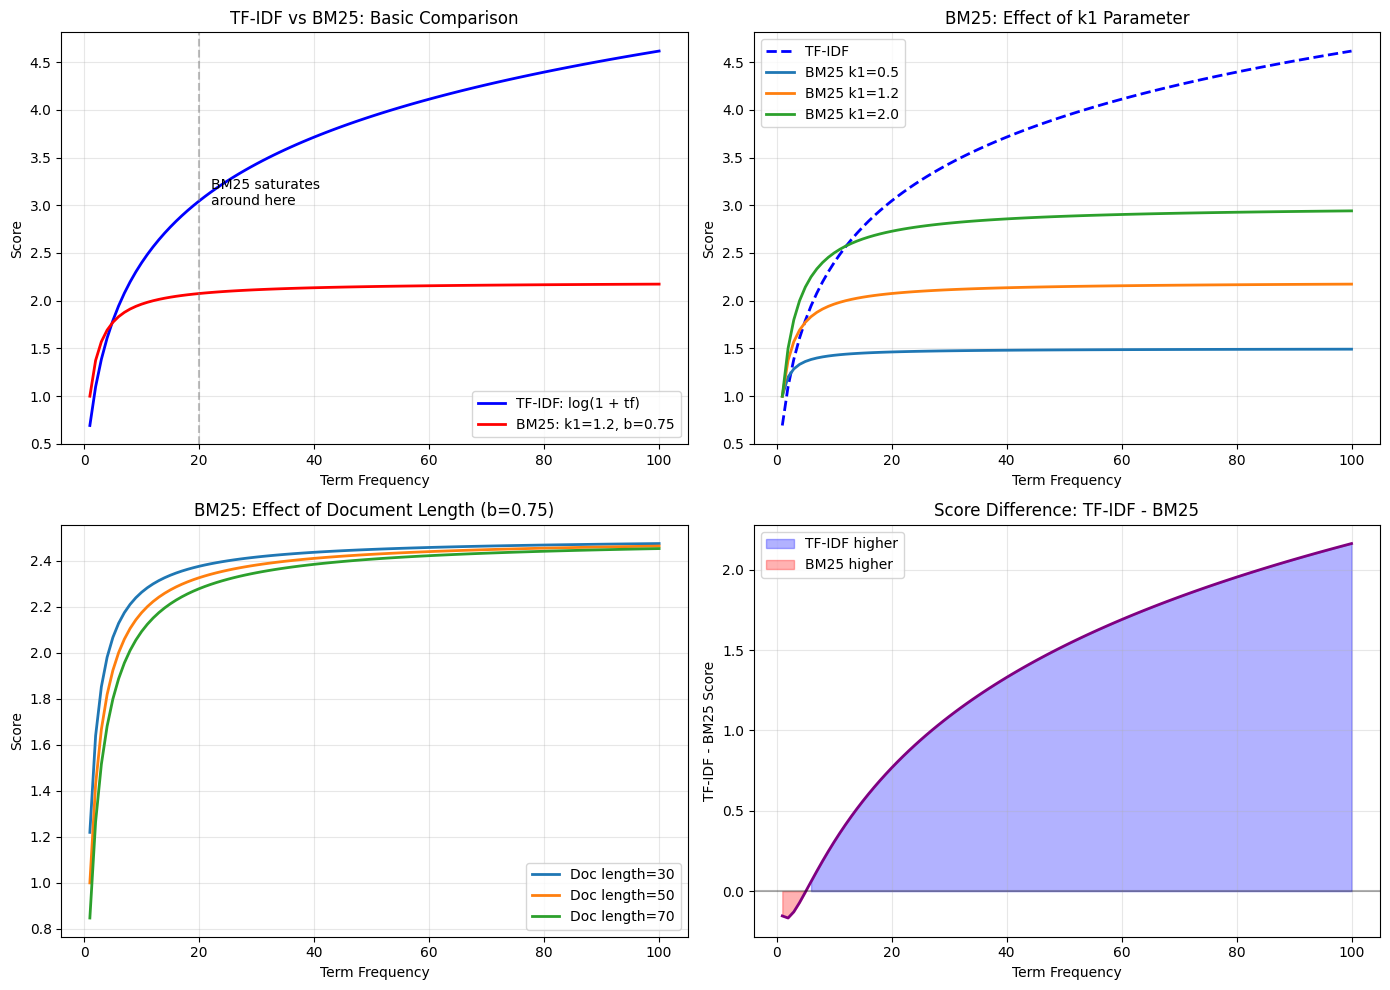



🎬 PRACTICAL COMPARISON: MOVIE SEARCH

Comparing retrieval results:


QUERY: 'zombie horror movie'

🔵 TF-IDF Top 5:
  1. Sharkskin                                (score: 0.5912)
  2. UnDivided                                (score: 0.5912)
  3. Crowsnest                                (score: 0.5912)
  4. Diamond Ruff                             (score: 0.5912)
  5. Hum To Mohabbat Karega                   (score: 0.5108)

🔴 BM25 Top 5:
  1. Halloween II                             (score: 10.0523)
  2. House of 1000 Corpses                    (score: 9.6566)
  3. Land of the Dead                         (score: 9.6566)
  4. Re-Kill                                  (score: 9.6566)
  5. Warm Bodies                              (score: 9.6566)

📊 Overlap: 0/5 movies in common

QUERY: 'Johnny Depp Orlando Bloom'

🔵 TF-IDF Top 5:
  1. Chocolat                                 (score: 0.4665)
  2. Fear and Loathing in Las Vegas           (score: 0.4371)
  3. Donnie Brasco                   

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
import matplotlib.pyplot as plt

# ============================================================================
# COMPARISON: TF-IDF vs BM25
# ============================================================================

print("=" * 80)
print("TF-IDF vs BM25 COMPARISON")
print("=" * 80)

# ============================================================================
# 1. THEORETICAL COMPARISON
# ============================================================================
print("\n📚 THEORETICAL DIFFERENCES\n")

comparison_table = pd.DataFrame({
    'Aspect': [
        'Term Frequency Formula',
        'Document Length',
        'Score Growth',
        'Saturation',
        'Best For',
        'Computational Cost'
    ],
    'TF-IDF': [
        'log(1 + tf)',
        'Normalized implicitly',
        'Logarithmic (never saturates)',
        'No saturation point',
        'Short documents, exact matches',
        'Lower (matrix operations)'
    ],
    'BM25': [
        'tf / (k1 + tf)',
        'Explicit normalization (b param)',
        'Asymptotic (saturates quickly)',
        'Saturates at k1/(1-b+b*dl/avgdl)',
        'Long documents, relevance ranking',
        'Higher (per-document calculation)'
    ]
})

print(comparison_table.to_string(index=False))

# ============================================================================
# 2. VISUAL COMPARISON OF SCORING FUNCTIONS
# ============================================================================
print("\n\n📊 SCORING FUNCTION COMPARISON\n")

frequencies = np.arange(1, 101)

# TF-IDF scoring (log normalization)
tfidf_scores = np.log(1 + frequencies)

# BM25 scoring with different parameters
k1_values = [0.5, 1.2, 2.0]
b = 0.75
avg_dl = 50
dl = 50  # document length

plt.figure(figsize=(14, 10))

# Plot 1: Basic comparison
plt.subplot(2, 2, 1)
bm25_scores = ((k1_values[1] + 1) * frequencies) / \
              (k1_values[1] * (1 - b + b * dl / avg_dl) + frequencies)

plt.plot(frequencies, tfidf_scores, label='TF-IDF: log(1 + tf)', 
         color='blue', linewidth=2)
plt.plot(frequencies, bm25_scores, label=f'BM25: k1={k1_values[1]}, b={b}', 
         color='red', linewidth=2)
plt.xlabel('Term Frequency')
plt.ylabel('Score')
plt.title('TF-IDF vs BM25: Basic Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate saturation point
saturation_freq = 20
plt.axvline(x=saturation_freq, color='gray', linestyle='--', alpha=0.5)
plt.text(saturation_freq + 2, 3, 'BM25 saturates\naround here', fontsize=10)

# Plot 2: Effect of k1 parameter
plt.subplot(2, 2, 2)
plt.plot(frequencies, tfidf_scores, label='TF-IDF', 
         color='blue', linewidth=2, linestyle='--')
for k1 in k1_values:
    bm25_scores = ((k1 + 1) * frequencies) / \
                  (k1 * (1 - b + b * dl / avg_dl) + frequencies)
    plt.plot(frequencies, bm25_scores, label=f'BM25 k1={k1}', linewidth=2)
plt.xlabel('Term Frequency')
plt.ylabel('Score')
plt.title('BM25: Effect of k1 Parameter')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Effect of document length (b parameter)
plt.subplot(2, 2, 3)
k1 = 1.5
b_values = [0, 0.5, 0.75, 1.0]
doc_lengths = [30, 50, 70]  # short, average, long

for dl in doc_lengths:
    bm25_scores = ((k1 + 1) * frequencies) / \
                  (k1 * (1 - 0.75 + 0.75 * dl / avg_dl) + frequencies)
    plt.plot(frequencies, bm25_scores, label=f'Doc length={dl}', linewidth=2)
plt.xlabel('Term Frequency')
plt.ylabel('Score')
plt.title('BM25: Effect of Document Length (b=0.75)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Relative difference
plt.subplot(2, 2, 4)
k1 = 1.5
bm25_scores = ((k1 + 1) * frequencies) / \
              (k1 * (1 - b + b * dl / avg_dl) + frequencies)
difference = tfidf_scores - bm25_scores

plt.plot(frequencies, difference, color='purple', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Term Frequency')
plt.ylabel('TF-IDF - BM25 Score')
plt.title('Score Difference: TF-IDF - BM25')
plt.grid(True, alpha=0.3)
plt.fill_between(frequencies, 0, difference, where=(difference > 0), 
                 alpha=0.3, color='blue', label='TF-IDF higher')
plt.fill_between(frequencies, 0, difference, where=(difference < 0), 
                 alpha=0.3, color='red', label='BM25 higher')
plt.legend()

plt.tight_layout()
plt.savefig('tfidf_vs_bm25_comparison.jpg', format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# 3. PRACTICAL COMPARISON ON MOVIE DATASET
# ============================================================================
print("\n\n🎬 PRACTICAL COMPARISON: MOVIE SEARCH\n")


from rank_bm25 import BM25Okapi

# Prepare documents for BM25 (needs tokenized text)
tokenized_docs = [doc.lower().split() for doc in _combined_features]
bm25 = BM25Okapi(tokenized_docs)

# Test queries
test_queries = [
    "zombie horror movie",
    "Johnny Depp Orlando Bloom",
    "romantic comedy love story",
    "A Qventin Tarantino film with Uma Thurman and John Travolta",
]

print("Comparing retrieval results:\n")

for query in test_queries:
    print(f"\n{'='*70}")
    print(f"QUERY: '{query}'")
    print('='*70)
    
    # TF-IDF approach
    query_tfidf = tfidf_vectorizer.transform([query])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix).flatten()
    tfidf_top_indices = tfidf_similarities.argsort()[-5:][::-1]
    
    # BM25 approach
    tokenized_query = query.lower().split()
    bm25_scores = bm25.get_scores(tokenized_query)
    bm25_top_indices = bm25_scores.argsort()[-5:][::-1]
    
    # Compare results
    print("\n🔵 TF-IDF Top 5:")
    for i, idx in enumerate(tfidf_top_indices, 1):
        print(f"  {i}. {ds.iloc[idx]['title']:40s} (score: {tfidf_similarities[idx]:.4f})")
    
    print("\n🔴 BM25 Top 5:")
    for i, idx in enumerate(bm25_top_indices, 1):
        print(f"  {i}. {ds.iloc[idx]['title']:40s} (score: {bm25_scores[idx]:.4f})")
    
    # Check overlap
    tfidf_set = set(tfidf_top_indices)
    bm25_set = set(bm25_top_indices)
    overlap = tfidf_set.intersection(bm25_set)
    
    print(f"\n📊 Overlap: {len(overlap)}/5 movies in common")
    if overlap:
        print(f"   Common movies: {[ds.iloc[idx]['title'] for idx in overlap]}")

# ============================================================================
# 4. PERFORMANCE METRICS
# ============================================================================
print("\n\n⚡ PERFORMANCE COMPARISON\n")

import time

query = "action adventure movie"

# Time TF-IDF
start = time.time()
query_tfidf = tfidf_vectorizer.transform([query])
tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix).flatten()
tfidf_top = tfidf_similarities.argsort()[-10:][::-1]
tfidf_time = time.time() - start

# Time BM25
start = time.time()
tokenized_query = query.lower().split()
bm25_scores = bm25.get_scores(tokenized_query)
bm25_top = bm25_scores.argsort()[-10:][::-1]
bm25_time = time.time() - start

performance_df = pd.DataFrame({
    'Method': ['TF-IDF', 'BM25'],
    'Time (ms)': [tfidf_time * 1000, bm25_time * 1000],
    'Speedup': [1.0, tfidf_time / bm25_time]
})

print(performance_df.to_string(index=False))

# ============================================================================
# 5. WHEN TO USE EACH
# ============================================================================
print("\n\n💡 RECOMMENDATIONS\n")

recommendations = """
USE TF-IDF WHEN:
✓ Documents are short and similar length
✓ You need fast retrieval with matrix operations
✓ Exact keyword matching is important
✓ You're building a simple search engine
✓ You want to combine with other ML algorithms (easy to vectorize)

USE BM25 WHEN:
✓ Documents vary significantly in length
✓ You need better ranking quality
✓ Multiple term occurrences are important (but with diminishing returns)
✓ You're building a production search engine
✓ You want state-of-the-art lexical search (used by Elasticsearch, Lucene)

HYBRID APPROACH:
→ Use BM25 for initial retrieval (top-k)
→ Re-rank with semantic embeddings (BERT, sentence-transformers)
→ This combines lexical + semantic search
"""

print(recommendations)

# ============================================================================
# 6. MATHEMATICAL FORMULAS
# ============================================================================
print("\n📐 MATHEMATICAL FORMULAS\n")

formulas = """
TF-IDF:
-------
score(q, d) = Σ [TF(t, d) × IDF(t)]
where:
  TF(t, d)  = log(1 + freq(t, d))
  IDF(t)    = log(N / df(t))
  N         = total documents
  df(t)     = documents containing term t

BM25:
-----
score(q, d) = Σ [IDF(t) × (TF(t,d) × (k₁ + 1)) / (TF(t,d) + k₁ × (1 - b + b × |d|/avgdl))]
where:
  k₁        = term frequency saturation parameter (typically 1.2-2.0)
  b         = length normalization parameter (typically 0.75)
  |d|       = document length
  avgdl     = average document length
  IDF(t)    = log((N - df(t) + 0.5) / (df(t) + 0.5))
"""

print(formulas)

print("\n" + "=" * 80)
print("COMPARISON COMPLETE")
print("=" * 80)